# Task 4 - Fine-tuning di un modello di linguaggio neurale (Neural Language Model).

In [1]:
# Da lanciare se non li hai installati nell'ambiente virtuale:
# !pip install transformers datasets accelerate evaluate

import os
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, TrainerCallback, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score
from datasets import Dataset
import pandas as pd
import evaluate
import seaborn as sns
import matplotlib.pyplot as plt

/home/tommaso/projects/lc2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("PyTorch vede la GPU?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Attuale (ID):", torch.cuda.current_device())
    print("Nome della GPU dedicata in uso:", torch.cuda.get_device_name(0))
else:
    print("ATTENZIONE: PyTorch sta usando solo la CPU!")

PyTorch vede la GPU? True
GPU Attuale (ID): 0
Nome della GPU dedicata in uso: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
df_train = pd.read_pickle('../data/processed/df_train_processed.pkl')
df_test = pd.read_pickle('../data/processed/df_test_processed.pkl')
df_val = pd.read_pickle('../data/processed/df_val_processed.pkl')

In [4]:
# Conversione da lista di dizionari a dataset
train = Dataset.from_pandas(pd.DataFrame(data=df_train[['text','label']]))
test = Dataset.from_pandas(pd.DataFrame(data=df_test[['text','label']]))
val = Dataset.from_pandas(pd.DataFrame(data=df_val[['text','label']]))

In [5]:
# Istanzio il tokenizzatore
model_name = "distilbert-base-cased"
output_model_path = "../finetuned_model"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6442.67it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=512)

# Qui applichi la funzione sovrascrivendo le variabili originali
train = train.map(tokenize, batched=True)
val = val.map(tokenize, batched=True)       # <-- Guarda qui! Tu l'avevi chiamata "validation" nel tuo blocco!
test = test.map(tokenize, batched=True)

train.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])
val.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])
test.set_format('numpy', columns=['input_ids', 'attention_mask', 'label'])
# Se qui sotto usi "validation" invece di "val", il formato NumPy non viene applicato al dataset giusto!

Map: 100%|██████████| 1000/1000 [00:00<00:00, 2873.22 examples/s]


Addestramento del modello

In [7]:
num_epochs = 3

# 1. Configurazione degli argomenti di addestramento
training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned",
    eval_strategy="epoch",        # Calcola le metriche sul validation a fine epoca
    logging_strategy="epoch",     # Registra i log di training a fine epoca
    save_strategy="epoch",        # Salva il checkpoint a fine epoca
    learning_rate=5e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,  # Ripristina il modello migliore alla fine
    metric_for_best_model="f1",   # Mantiene come riferimento l'F1-score
    greater_is_better=True
)

In [8]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = evaluate.load("f1").compute(predictions=predictions, references=labels, average="weighted")["f1"]
    acc = accuracy_score(labels, predictions)
    return {"f1": f1, "accuracy": acc}

In [9]:
# 3. Inizializzazione del Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train,      # Usa i dataset tokenizzati del passo precedente
    eval_dataset=val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# 4. Lancio del Fine-Tuning
print(f"Inizio del Fine-Tuning di DistilBERT ({num_epochs} epoche)...")
trainer.train()

Inizio del Fine-Tuning di DistilBERT (3 epoche)...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.410488,0.306302,0.887126,0.888000
2,0.217243,0.275225,0.917742,0.918000
3,0.180170,0.230848,0.935996,0.936000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


TrainOutput(global_step=750, training_loss=0.2693003692626953, metrics={'train_runtime': 377.5162, 'train_samples_per_second': 15.893, 'train_steps_per_second': 1.987, 'total_flos': 794804391936000.0, 'train_loss': 0.2693003692626953, 'epoch': 3.0})

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.00it/s]


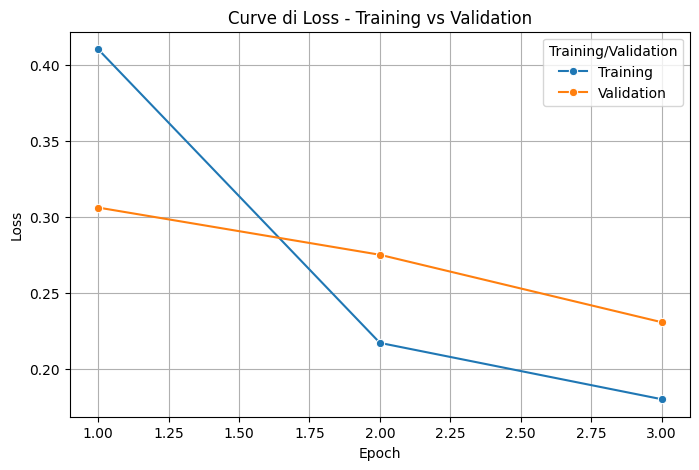

In [10]:
# 5. Salvataggio del modello finale
trainer.save_model("../finetuned_model")

# 6. Estrazione della cronologia per le curve di Loss
log_history = trainer.state.log_history

# Creazione del dataframe per raccogliere le loss
df_loss = pd.DataFrame(columns=["Epoch", "Loss", "Training/Validation"])

for log_data in log_history:
    # Gestiamo l'epoca come float per evitare sovrascritture se ci sono frazioni
    epoch = log_data["epoch"] 
    
    if "loss" in log_data:
        log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [log_data["loss"]], "Training/Validation": ["Training"]})
        df_loss = pd.concat([df_loss, log_df], ignore_index=True)
        
    if "eval_loss" in log_data:
        log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [log_data["eval_loss"]], "Training/Validation": ["Validation"]})
        df_loss = pd.concat([df_loss, log_df], ignore_index=True)

# 7. Grafico a linee della Loss
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_loss, x="Epoch", y="Loss", hue="Training/Validation", marker="o")
plt.title("Curve di Loss - Training vs Validation")
plt.grid(True)
plt.savefig("curve_loss_distilbert.png") # Salva il grafico per la relazione
plt.show()

In [11]:
for log in trainer.state.log_history:
    if "eval_f1" in log:
        print(f"Epoca {int(log['epoch'])}: F1 = {log['eval_f1']:.4f}, Loss = {log['eval_loss']:.4f}")

Epoca 1: F1 = 0.8871, Loss = 0.3063
Epoca 2: F1 = 0.9177, Loss = 0.2752
Epoca 3: F1 = 0.9360, Loss = 0.2308


### Predizione sul test set del modello migliore (considerando il valore di F1-score sul validation set)

In [12]:
output_predictions = trainer.predict(test)

In [13]:
# 1. Estraiamo i logits (i punteggi grezzi) e i target reali dal test set
logits = output_predictions.predictions
y_true_test = output_predictions.label_ids

# 2. Trasformiamo i logits in predizioni discrete (0 o 1) prendendo l'indice del valore massimo
y_pred_test = np.argmax(logits, axis=1)

# 3. Stampiamo il classification report definitivo sul Test Set
print("\n--- REPORT FINALE DISTILBERT (TEST SET) ---")
print(classification_report(y_true_test, y_pred_test, zero_division=0))


--- REPORT FINALE DISTILBERT (TEST SET) ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       500
           1       0.92      0.88      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000

